# GPT-2: Vanilla vs RSR (Human Behavioral Similarity)

## Experiment Pipeline

**Goal**: Compare two GPT-2 models on semantic similarity:
1. **Vanilla**: Pre-trained GPT-2 (no fine-tuning)
2. **RSR**: GPT-2 fine-tuned with Human similarity judgments (4.7M triplets)

### Pipeline Steps:
1. Load Wikipedia corpus
2. Load human behavioral similarity matrix (THINGS dataset)
3. Load THINGS concepts
4. Load GPT-2 and map THINGS concepts to token embeddings
5. Extract **VANILLA** embeddings (pre-trained GPT-2)
6. Fine-tune **RSR** GPT-2 (LM loss + human similarity alignment)
7. Evaluate both on **SimLex-999** benchmark (human similarity ratings)

### RSR Approach: Two-Component Loss

The RSR model uses a **two-component loss** to balance language modeling with human similarity alignment:

**Loss Function:**
```
L_total = LM_WEIGHT × L_lm + RSR_WEIGHT × L_rsr
```

**Components:**
1. **L_lm** (0.9): Causal language modeling loss on Wikipedia corpus
   - Standard next-token prediction
   - Preserves GPT-2's language understanding

2. **L_rsr** (0.1): Human similarity alignment
   - Soft Spearman correlation with human behavioral similarity
   - `L_rsr = 1 - soft_spearman(model_sim, human_sim)`
   - Uses random sampling of concept pairs for efficiency

### Key Differences from Word2Vec

1. **Pre-trained**: GPT-2 is already trained on massive text data
2. **BPE Tokenization**: Words may be split into multiple tokens
3. **Embedding Extraction**: For multi-token words, we average token embeddings
4. **Fine-tuning**: We fine-tune the embedding layer (wte) rather than training from scratch

### Evaluation: SimLex-999 Benchmark

We evaluate using **SimLex-999**, a gold-standard benchmark for semantic similarity.

To test generalization, we split word pairs into three categories:
- **Both in THINGS**: Both words were used during RSR training → tests direct learning
- **One in THINGS**: Only one word was used → tests partial transfer
- **Neither in THINGS**: Neither word was used → tests true generalization


## Step 1: Imports & Configuration


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import scipy.io as sio

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config

# Configuration
BASE_DATA_DIR = "data"
THINGS_DIR = "things_similarity"

# Corpus path (text file, one sentence per line)
CORPUS_PATH = os.path.join(BASE_DATA_DIR, "AllCombined.txt")

# THINGS paths
THINGS_WORDS_PATH = os.path.join(THINGS_DIR, "variables", "unique_id.txt")
BEHAVIORAL_SIM_PATH = os.path.join(THINGS_DIR, "data", "spose_similarity.mat")
CATEGORY_DATA_PATH = os.path.join(THINGS_DIR, "data", "category_mat_manual.mat")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Using device: cuda


## Step 2: Load Wikipedia Corpus


In [2]:
print("="*70)
print("STEP 2: Loading Wikipedia Corpus")
print("="*70)

import re
from pathlib import Path

def load_corpus_lines(corpus_path: Path, max_lines=None):
    """Load corpus as list of text lines."""
    lines = []
    with corpus_path.open("r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines:
                break
            line = line.strip()
            if line and len(line) > 20:  # Skip very short lines
                lines.append(line)
    return lines

corpus_path = Path(CORPUS_PATH)
corpus_lines = load_corpus_lines(corpus_path)

print(f"  Source: Wikipedia corpus (AllCombined.txt)")
print(f"  Lines: {len(corpus_lines):,}")
if corpus_lines:
    print(f"  Sample: {corpus_lines[0][:80]}...")


STEP 2: Loading Wikipedia Corpus
  Source: Wikipedia corpus (AllCombined.txt)
  Lines: 754,109
  Sample: April (Apr.) is the fourth month of the year in the Julian and Gregorian calenda...


## Step 3: Load Human Behavioral Similarity Matrix


In [3]:
print("="*70)
print("STEP 3: Loading Human Behavioral Similarity Matrix")
print("="*70)

# Load full behavioral similarity matrix (1854 x 1854 THINGS concepts)
behav_data = sio.loadmat(BEHAVIORAL_SIM_PATH)
behav_sim_full = behav_data['spose_sim']

print(f"  Source: 4.7 million human triplet judgments")
print(f"  Matrix shape: {behav_sim_full.shape}")
print(f"  Similarity range: [{behav_sim_full.min():.3f}, {behav_sim_full.max():.3f}]")
print(f"  Mean similarity: {behav_sim_full.mean():.3f}")


STEP 3: Loading Human Behavioral Similarity Matrix
  Source: 4.7 million human triplet judgments
  Matrix shape: (1854, 1854)
  Similarity range: [0.052, 1.000]
  Mean similarity: 0.334


## Step 4: Load THINGS Concepts & Category Labels


In [4]:
print("="*70)
print("STEP 4: Loading THINGS Concepts & Category Labels")
print("="*70)

# Load THINGS concepts (one word per line)
def load_things_words(words_path):
    """Load THINGS word list (one word per line)."""
    words = []
    with open(words_path, "r", encoding="utf-8") as f:
        for line in f:
            word = line.strip()
            if word:
                words.append(word)
    return words

concepts = load_things_words(THINGS_WORDS_PATH)
print(f"  THINGS concepts: {len(concepts)}")

# Load Category27 labels from .mat file
category_data = sio.loadmat(CATEGORY_DATA_PATH)

# Find the category matrix
Y_all = None
for key in category_data.keys():
    if not key.startswith('__'):
        arr = category_data[key]
        if isinstance(arr, np.ndarray) and len(arr.shape) == 2:
            if arr.shape[0] > 100 or arr.shape[1] > 100:
                Y_all = arr.astype(np.float32)
                print(f"  Using '{key}' as category labels")
                break

if Y_all is None:
    Y_all = np.zeros((len(concepts), 27), dtype=np.float32)
    print("  WARNING: Using dummy category labels")

# Transpose if needed (should be concepts x categories)
if Y_all.shape[0] == 27 and Y_all.shape[1] > 100:
    Y_all = Y_all.T

print(f"  Category labels: {Y_all.shape}")


STEP 4: Loading THINGS Concepts & Category Labels
  THINGS concepts: 1854
  Using 'category_mat_manual' as category labels
  Category labels: (1854, 27)


## Step 5: Load GPT-2 & Align THINGS Concepts


In [5]:
print("="*70)
print("STEP 5: Loading GPT-2 & Aligning THINGS Concepts")
print("="*70)

# Load GPT-2 tokenizer and model
print("\nLoading GPT-2 (small)...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 doesn't have a pad token by default

# We'll create two models: one for vanilla (frozen), one for RSR (fine-tuned)
vanilla_model = GPT2LMHeadModel.from_pretrained('gpt2').to(DEVICE)
vanilla_model.eval()  # Freeze for evaluation

print(f"  Model: GPT-2 (small)")
print(f"  Vocabulary size: {tokenizer.vocab_size:,}")
print(f"  Embedding dim: {vanilla_model.config.n_embd}")
print(f"  Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")

EMBEDDING_DIM = vanilla_model.config.n_embd  # 768 for GPT-2 small


STEP 5: Loading GPT-2 & Aligning THINGS Concepts

Loading GPT-2 (small)...
  Model: GPT-2 (small)
  Vocabulary size: 50,257
  Embedding dim: 768
  Parameters: 124,439,808


In [6]:
# ============================================================================
# Map THINGS concepts to GPT-2 token embeddings
# ============================================================================
# GPT-2 uses BPE tokenization, so some words are split into multiple tokens.
# For multi-token words, we average the token embeddings.

def get_word_embedding(word, model, tokenizer, device):
    """
    Get embedding for a word from GPT-2.
    For multi-token words, average the token embeddings.
    
    Args:
        word: The word to embed
        model: GPT-2 model
        tokenizer: GPT-2 tokenizer
        device: torch device
    
    Returns:
        embedding: numpy array of shape (embedding_dim,)
        token_ids: list of token IDs for this word
    """
    # Clean the word (replace underscores with spaces for compound words)
    word_clean = word.replace("_", " ").lower()
    
    # Tokenize
    tokens = tokenizer.encode(word_clean, add_special_tokens=False)
    
    if not tokens:
        return None, []
    
    # Get token embeddings from the embedding layer (wte)
    token_tensor = torch.tensor(tokens, device=device)
    with torch.no_grad():
        embeddings = model.transformer.wte(token_tensor)  # (n_tokens, embedding_dim)
    
    # Average if multiple tokens
    avg_embedding = embeddings.mean(dim=0).cpu().numpy()
    
    return avg_embedding, tokens

def get_word_embedding_trainable(word, model, tokenizer, device):
    """
    Get embedding for a word from GPT-2 (trainable version, keeps gradients).
    """
    word_clean = word.replace("_", " ").lower()
    tokens = tokenizer.encode(word_clean, add_special_tokens=False)
    
    if not tokens:
        return None, []
    
    token_tensor = torch.tensor(tokens, device=device)
    embeddings = model.transformer.wte(token_tensor)
    avg_embedding = embeddings.mean(dim=0)  # Keep as tensor for gradients
    
    return avg_embedding, tokens

# Align THINGS concepts with GPT-2 vocabulary
print("\nAligning THINGS concepts with GPT-2 vocabulary...")

valid_concepts = []
valid_things_indices = []
concept_tokens = {}  # concept -> list of token IDs
Y_rows = []

for idx, concept in enumerate(tqdm(concepts, desc="Mapping concepts")):
    emb, tokens = get_word_embedding(concept, vanilla_model, tokenizer, DEVICE)
    
    if emb is not None and len(tokens) > 0:
        valid_concepts.append(concept)
        valid_things_indices.append(idx)
        concept_tokens[concept] = tokens
        Y_rows.append(Y_all[idx])

# Stack category labels
Y = np.stack(Y_rows, axis=0).astype(np.float32)

# Extract aligned similarity matrix
behav_sim_subset = behav_sim_full[np.ix_(valid_things_indices, valid_things_indices)]
behav_sim_target = torch.tensor(behav_sim_subset, dtype=torch.float32, device=DEVICE)

print(f"\n  Matched: {len(valid_concepts)} / {len(concepts)} concepts")
print(f"  Category labels Y: {Y.shape}")
print(f"  Similarity matrix: {behav_sim_subset.shape}")

# Show tokenization examples
print(f"\nTokenization examples:")
for concept in valid_concepts[:5]:
    tokens = concept_tokens[concept]
    decoded = [tokenizer.decode([t]) for t in tokens]
    print(f"  '{concept}' -> {decoded} ({len(tokens)} tokens)")



Aligning THINGS concepts with GPT-2 vocabulary...


Mapping concepts: 100%|██████████| 1854/1854 [00:00<00:00, 4319.62it/s]


  Matched: 1854 / 1854 concepts
  Category labels Y: (1854, 27)
  Similarity matrix: (1854, 1854)

Tokenization examples:
  'aardvark' -> ['a', 'ard', 'v', 'ark'] (4 tokens)
  'abacus' -> ['ab', 'acus'] (2 tokens)
  'accordion' -> ['acc', 'ord', 'ion'] (3 tokens)
  'acorn' -> ['ac', 'orn'] (2 tokens)
  'air_conditioner' -> ['air', ' condition', 'er'] (3 tokens)


## Step 6: Define Training Functions


In [ ]:
# ============================================================================
# HYPERPARAMETERS
# ============================================================================
BATCH_SIZE = 4  # Smaller batch size for GPT-2 (memory constraints)
MAX_SEQ_LEN = 128  # Maximum sequence length for LM training
BATCHES_PER_EPOCH = 2000  # Fewer batches since GPT-2 is more expensive
GPT2_EPOCHS = 3
GPT2_LR = 1e-5  # Lower learning rate for fine-tuning

# ============================================================================
# LOSS WEIGHTS
# ============================================================================
LM_WEIGHT = 0.7       # Language modeling loss
RSR_WEIGHT = 0.3      # Human similarity alignment

# RSR sampling
RSR_SAMPLE_SIZE = 5000  # match main.ipynb
RSR_EVERY_N_BATCHES = 5  # Apply RSR every N batches

# ============================================================================
# Soft Spearman Correlation (same as Word2Vec version)
# ============================================================================

def soft_rank(x, regularization_strength=1.0):
    """
    Differentiable soft ranking using pairwise comparisons with sigmoid.
    """
    n = x.shape[0]
    
    if n > 10000:
        _, indices = torch.sort(x)
        ranks = torch.zeros_like(x)
        ranks[indices] = torch.arange(1, n + 1, dtype=x.dtype, device=x.device)
        return ranks
    
    x_expanded = x.unsqueeze(1)
    diffs = x_expanded - x.unsqueeze(0)
    soft_comparisons = torch.sigmoid(regularization_strength * diffs)
    ranks = soft_comparisons.sum(dim=1)
    
    return ranks


def soft_spearman(pred, target, regularization_strength=1.0):
    """
    Differentiable Spearman correlation using soft ranking.
    """
    pred_ranked = soft_rank(pred, regularization_strength)
    target_ranked = soft_rank(target, regularization_strength)
    
    pred_ranked = pred_ranked - pred_ranked.mean()
    pred_ranked = pred_ranked / (pred_ranked.norm() + 1e-8)
    
    target_ranked = target_ranked - target_ranked.mean()
    target_ranked = target_ranked / (target_ranked.norm() + 1e-8)
    
    return (pred_ranked * target_ranked).sum()

# ============================================================================
# Dataset for Language Modeling
# ============================================================================

class WikiTextDataset(Dataset):
    """Dataset for causal language modeling on Wikipedia text."""
    
    def __init__(self, lines, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.lines = lines
    
    def __len__(self):
        return len(self.lines)
    
    def __getitem__(self, idx):
        text = self.lines[idx]
        
        # Tokenize with truncation
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': input_ids.clone()  # For causal LM, labels = input_ids
        }

print(f"{'='*70}")
print("MODEL CONFIGURATION:")
print(f"{'='*70}")
print(f"  Model: GPT-2 (small)")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Batches per epoch: {BATCHES_PER_EPOCH}")
print(f"  Epochs: {GPT2_EPOCHS}")
print(f"  Learning rate: {GPT2_LR}")
print(f"{'='*70}")
print(f"\nTWO-COMPONENT LOSS:")
print(f"{'='*70}")
print(f"  L_total = {LM_WEIGHT} * L_lm + {RSR_WEIGHT} * L_rsr")
print(f"  ")
print(f"  Components:")
print(f"    L_lm ({LM_WEIGHT}):   Causal language modeling")
print(f"    L_rsr ({RSR_WEIGHT}):  Human similarity alignment (soft Spearman)")
print(f"  ")
print(f"  RSR frequency: every {RSR_EVERY_N_BATCHES} batch(es)")
print(f"{'='*70}")


MODEL CONFIGURATION:
  Model: GPT-2 (small)
  Embedding dim: 768
  Max sequence length: 128
  Batch size: 4
  Batches per epoch: 2000
  Epochs: 3
  Learning rate: 1e-05

TWO-COMPONENT LOSS:
  L_total = 0.7 * L_lm + 0.3 * L_rsr
  
  Components:
    L_lm (0.7):   Causal language modeling
    L_rsr (0.3):  Human similarity alignment (soft Spearman)
  
  RSR frequency: every 5 batch(es)


## Step 7: Extract VANILLA GPT-2 Embeddings


In [8]:
print("="*70)
print("STEP 7: Extracting VANILLA GPT-2 Embeddings")
print("="*70)
print("Using pre-trained GPT-2 (no fine-tuning)")
print("="*70 + "\n")

# Extract embeddings for all valid concepts
vanilla_model.eval()
X_vanilla = []

for concept in tqdm(valid_concepts, desc="Extracting vanilla embeddings"):
    emb, _ = get_word_embedding(concept, vanilla_model, tokenizer, DEVICE)
    X_vanilla.append(emb)

X_vanilla = np.stack(X_vanilla, axis=0)
print(f"\n✓ Vanilla embeddings extracted: {X_vanilla.shape}")


STEP 7: Extracting VANILLA GPT-2 Embeddings
Using pre-trained GPT-2 (no fine-tuning)



Extracting vanilla embeddings: 100%|██████████| 1854/1854 [00:00<00:00, 6716.54it/s]


✓ Vanilla embeddings extracted: (1854, 768)


## Step 8: Train RSR GPT-2 (LM + Human Similarity)


In [9]:
print("="*70)
print("STEP 8: Training RSR GPT-2 (LM + Human Similarity)")
print("="*70)
print("Fine-tuning GPT-2 with language modeling + RSR alignment")
print("="*70 + "\n")

# Create a fresh GPT-2 model for RSR training
rsr_model = GPT2LMHeadModel.from_pretrained('gpt2').to(DEVICE)

# Only fine-tune the embedding layer (wte) to match Word2Vec experiment
# Freeze all other parameters
for name, param in rsr_model.named_parameters():
    if 'wte' not in name:  # Only train word token embeddings
        param.requires_grad = False

trainable_params = sum(p.numel() for p in rsr_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in rsr_model.parameters())
print(f"  Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# Setup optimizer
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, rsr_model.parameters()),
    lr=GPT2_LR
)

# Create dataset and dataloader
dataset = WikiTextDataset(corpus_lines, tokenizer, MAX_SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Pre-compute indices for RSR sampling
n_concepts = behav_sim_target.shape[0]
all_triu_indices = torch.triu_indices(n_concepts, n_concepts, offset=1, device=DEVICE)
total_pairs = all_triu_indices.shape[1]

# Precompute concept token tensors for efficient embedding lookup
concept_token_tensors = []
for concept in valid_concepts:
    tokens = concept_tokens[concept]
    concept_token_tensors.append(torch.tensor(tokens, device=DEVICE))

print(f"\nTraining...")
print(f"Expected time: ~{GPT2_EPOCHS * BATCHES_PER_EPOCH // 100} minutes\n")


STEP 8: Training RSR GPT-2 (LM + Human Similarity)
Fine-tuning GPT-2 with language modeling + RSR alignment

  Trainable parameters: 38,597,376 / 124,439,808 (31.0%)

Training...
Expected time: ~60 minutes



In [10]:
# Training loop
rsr_model.train()

for epoch in range(GPT2_EPOCHS):
    total_lm_loss, total_rsr_loss, total_combined_loss = 0, 0, 0
    total_spearman = 0
    rsr_count = 0
    
    data_iter = iter(dataloader)
    pbar = tqdm(range(BATCHES_PER_EPOCH), desc=f"RSR Epoch {epoch+1}/{GPT2_EPOCHS}")
    
    for batch_idx in pbar:
        # Get next batch (cycle through dataset if needed)
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)
        
        # Move to device
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        
        # =====================================================================
        # Component 1: Language Modeling Loss
        # =====================================================================
        outputs = rsr_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        L_lm = outputs.loss
        
        # =====================================================================
        # Component 2: RSR Loss (every N batches)
        # =====================================================================
        L_rsr = torch.tensor(0.0, device=DEVICE)
        spearman_corr = torch.tensor(0.0, device=DEVICE)
        
        if batch_idx % RSR_EVERY_N_BATCHES == 0:
            # Sample random concept pairs
            sample_indices = torch.randperm(total_pairs, device=DEVICE)[:RSR_SAMPLE_SIZE]
            sampled_i = all_triu_indices[0, sample_indices]
            sampled_j = all_triu_indices[1, sample_indices]
            
            # Get target similarities
            target_sim_sample = behav_sim_target[sampled_i, sampled_j]
            
            # Get concept embeddings (average of token embeddings)
            concept_embeddings = []
            for token_tensor in concept_token_tensors:
                emb = rsr_model.transformer.wte(token_tensor).mean(dim=0)
                concept_embeddings.append(emb)
            concept_embeddings = torch.stack(concept_embeddings, dim=0)  # (n_concepts, emb_dim)
            
            # Normalize embeddings
            concept_embeddings_norm = F.normalize(concept_embeddings, p=2, dim=1)
            
            # Compute model similarities for sampled pairs
            model_sim_sample = (concept_embeddings_norm[sampled_i] * concept_embeddings_norm[sampled_j]).sum(dim=1)
            
            # Compute soft Spearman correlation
            spearman_corr = soft_spearman(model_sim_sample, target_sim_sample)
            
            # RSR loss
            L_rsr = 1.0 - spearman_corr
            
            rsr_count += 1
            total_spearman += spearman_corr.item()
        
        # =====================================================================
        # Combined loss
        # =====================================================================
        L_total = LM_WEIGHT * L_lm + RSR_WEIGHT * L_rsr
        
        optimizer.zero_grad()
        L_total.backward()
        optimizer.step()
        
        total_lm_loss += L_lm.item()
        total_rsr_loss += L_rsr.item()
        total_combined_loss += L_total.item()
        
        if batch_idx % 50 == 0:
            pbar.set_postfix({
                'lm': f'{L_lm.item():.3f}',
                'rsr': f'{L_rsr.item():.3f}',
                'ρ': f'{spearman_corr.item():.3f}'
            })
    
    avg_lm = total_lm_loss / BATCHES_PER_EPOCH
    avg_rsr = total_rsr_loss / max(1, rsr_count)
    avg_combined = total_combined_loss / BATCHES_PER_EPOCH
    avg_spearman = total_spearman / max(1, rsr_count)
    print(f"Epoch {epoch+1} | LM: {avg_lm:.4f} | RSR: {avg_rsr:.4f} | Total: {avg_combined:.4f} | ρ: {avg_spearman:.4f}")

print(f"\n✓ RSR GPT-2 training complete!")
print(f"  Final Spearman correlation with human similarity: {avg_spearman:.4f}")


RSR Epoch 1/3: 100%|██████████| 2000/2000 [11:45<00:00,  2.83it/s, lm=2.262, rsr=0.965, ρ=0.035]


Epoch 1 | LM: 2.8186 | RSR: 0.9424 | Total: 2.0296 | ρ: 0.0576


RSR Epoch 2/3: 100%|██████████| 2000/2000 [12:13<00:00,  2.73it/s, lm=1.244, rsr=0.908, ρ=0.092]


Epoch 2 | LM: 1.5393 | RSR: 0.9350 | Total: 1.1336 | ρ: 0.0650


RSR Epoch 3/3: 100%|██████████| 2000/2000 [12:11<00:00,  2.73it/s, lm=0.860, rsr=0.948, ρ=0.052]

Epoch 3 | LM: 1.4980 | RSR: 0.9247 | Total: 1.1040 | ρ: 0.0753

✓ RSR GPT-2 training complete!
  Final Spearman correlation with human similarity: 0.0753


In [11]:
# Extract RSR embeddings
rsr_model.eval()
X_rsr = []

for concept in tqdm(valid_concepts, desc="Extracting RSR embeddings"):
    emb, _ = get_word_embedding(concept, rsr_model, tokenizer, DEVICE)
    X_rsr.append(emb)

X_rsr = np.stack(X_rsr, axis=0)
print(f"\n✓ RSR embeddings extracted: {X_rsr.shape}")


Extracting RSR embeddings: 100%|██████████| 1854/1854 [00:00<00:00, 6543.16it/s]


✓ RSR embeddings extracted: (1854, 768)


## Step 9: Evaluate on SimLex-999 (Human Similarity Benchmark)


In [12]:
from scipy.stats import spearmanr
from numpy.linalg import norm

print("="*70)
print("STEP 9: SimLex-999 Evaluation")
print("="*70)
print("Benchmark: SimLex-999 (999 word pairs with human similarity ratings)")
print("Metric: Spearman correlation between model similarity and human ratings")
print("="*70 + "\n")

# Load SimLex-999
SIMLEX_PATH = "SimLex-999/SimLex-999.txt"
simlex_df = pd.read_csv(SIMLEX_PATH, sep="\t")
print(f"Loaded SimLex-999: {len(simlex_df)} word pairs")
print(f"  Parts of speech: {simlex_df['POS'].value_counts().to_dict()}")

# Create THINGS concept set (lowercase for matching)
things_concepts_lower = set(c.lower().replace("_", " ") for c in valid_concepts)
print(f"  THINGS concepts (for RSR training): {len(things_concepts_lower)}")

# Categorize each SimLex pair based on THINGS overlap
def categorize_pair(word1, word2, things_set):
    """Categorize pair based on whether words appear in THINGS."""
    w1_lower, w2_lower = word1.lower(), word2.lower()
    in_things_1 = w1_lower in things_set
    in_things_2 = w2_lower in things_set
    
    if in_things_1 and in_things_2:
        return "both_in_things"
    elif not in_things_1 and not in_things_2:
        return "neither_in_things"
    else:
        return "one_in_things"

simlex_df["category"] = simlex_df.apply(
    lambda row: categorize_pair(row["word1"], row["word2"], things_concepts_lower), 
    axis=1
)

print(f"\nSimLex-999 pair categories:")
for cat, count in simlex_df["category"].value_counts().items():
    print(f"  {cat}: {count} pairs")


STEP 9: SimLex-999 Evaluation
Benchmark: SimLex-999 (999 word pairs with human similarity ratings)
Metric: Spearman correlation between model similarity and human ratings

Loaded SimLex-999: 999 word pairs
  Parts of speech: {'N': 666, 'V': 222, 'A': 111}
  THINGS concepts (for RSR training): 1854

SimLex-999 pair categories:
  neither_in_things: 708 pairs
  one_in_things: 187 pairs
  both_in_things: 104 pairs


In [13]:
# Build embedding dictionaries using GPT-2
def build_gpt2_embedding_dict(model, tokenizer, words, device):
    """Build word -> embedding dictionary using GPT-2."""
    embeddings = {}
    model.eval()
    
    for word in tqdm(words, desc="Building embedding dict"):
        emb, tokens = get_word_embedding(word, model, tokenizer, device)
        if emb is not None:
            embeddings[word.lower()] = emb
    
    return embeddings

# Get all unique words from SimLex-999
simlex_words = set(simlex_df['word1'].str.lower().tolist() + simlex_df['word2'].str.lower().tolist())
print(f"\nBuilding embedding dictionaries for {len(simlex_words)} SimLex words...")

vanilla_emb_dict = build_gpt2_embedding_dict(vanilla_model, tokenizer, simlex_words, DEVICE)
rsr_emb_dict = build_gpt2_embedding_dict(rsr_model, tokenizer, simlex_words, DEVICE)

print(f"  Vanilla dict: {len(vanilla_emb_dict)} words")
print(f"  RSR dict: {len(rsr_emb_dict)} words")



Building embedding dictionaries for 1028 SimLex words...


Building embedding dict: 100%|██████████| 1028/1028 [00:00<00:00, 6630.70it/s]

  Vanilla dict: 1028 words
  RSR dict: 1028 words


In [14]:
# Evaluation function
def evaluate_simlex(embeddings_dict, simlex_df, category="all"):
    """Compute Spearman correlation between model cosine similarity and human ratings."""
    if category == "all":
        subset = simlex_df
    else:
        subset = simlex_df[simlex_df["category"] == category]
    
    model_sims = []
    human_sims = []
    found_pairs = 0
    
    for _, row in subset.iterrows():
        w1, w2 = row["word1"].lower(), row["word2"].lower()
        
        if w1 not in embeddings_dict or w2 not in embeddings_dict:
            continue
        
        found_pairs += 1
        
        vec1 = embeddings_dict[w1]
        vec2 = embeddings_dict[w2]
        cos_sim = np.dot(vec1, vec2) / (norm(vec1) * norm(vec2) + 1e-8)
        
        model_sims.append(cos_sim)
        human_sims.append(row["SimLex999"])
    
    if len(model_sims) < 2:
        return {"correlation": float("nan"), "p_value": float("nan"), 
                "n_pairs": 0, "coverage": 0.0}
    
    corr, pval = spearmanr(model_sims, human_sims)
    coverage = found_pairs / len(subset) * 100
    
    return {"correlation": corr, "p_value": pval, "n_pairs": found_pairs, "coverage": coverage}

# Run evaluation for all categories
categories = ["all", "both_in_things", "one_in_things", "neither_in_things"]

vanilla_results = {}
rsr_results = {}

for cat in categories:
    vanilla_results[cat] = evaluate_simlex(vanilla_emb_dict, simlex_df, cat)
    rsr_results[cat] = evaluate_simlex(rsr_emb_dict, simlex_df, cat)

# Print results
print("\n" + "="*80)
print("RESULTS: SimLex-999 Evaluation (Spearman ρ)")
print("="*80)
print(f"{'Category':<22} {'N pairs':>8} {'Coverage':>10} {'Vanilla ρ':>12} {'RSR ρ':>12} {'Δ':>10}")
print("-"*80)

for cat in categories:
    v = vanilla_results[cat]
    r = rsr_results[cat]
    delta = r["correlation"] - v["correlation"]
    
    cat_display = cat.replace("_", " ").title() if cat != "all" else "ALL PAIRS"
    
    print(f"{cat_display:<22} {r['n_pairs']:>8} {r['coverage']:>9.1f}% "
          f"{v['correlation']:>12.4f} {r['correlation']:>12.4f} {delta:>+10.4f}")

print("="*80)

# Summary interpretation
all_delta = rsr_results["all"]["correlation"] - vanilla_results["all"]["correlation"]
both_delta = rsr_results["both_in_things"]["correlation"] - vanilla_results["both_in_things"]["correlation"]
neither_delta = rsr_results["neither_in_things"]["correlation"] - vanilla_results["neither_in_things"]["correlation"]

print(f"\n{'='*80}")
print("INTERPRETATION:")
print("="*80)

if all_delta > 0.01:
    print(f"✓ RSR improved overall SimLex-999 correlation by {all_delta:+.4f}")
else:
    print(f"  Overall change: {all_delta:+.4f}")

if both_delta > 0.02:
    print(f"✓ Strongest improvement for 'both in THINGS' pairs: {both_delta:+.4f}")

if neither_delta > 0.01:
    print(f"✓ RSR generalizes! Improvement on unseen word pairs: {neither_delta:+.4f}")
elif neither_delta > 0:
    print(f"~ Slight generalization to unseen words: {neither_delta:+.4f}")
else:
    print(f"  No generalization to unseen words: {neither_delta:+.4f}")

print("="*80)



RESULTS: SimLex-999 Evaluation (Spearman ρ)
Category                N pairs   Coverage    Vanilla ρ        RSR ρ          Δ
--------------------------------------------------------------------------------
ALL PAIRS                   999     100.0%       0.2781       0.2757    -0.0024
Both In Things              104     100.0%       0.1895       0.2162    +0.0267
One In Things               187     100.0%       0.3467       0.3282    -0.0185
Neither In Things           708     100.0%       0.2380       0.2358    -0.0022

INTERPRETATION:
  Overall change: -0.0024
✓ Strongest improvement for 'both in THINGS' pairs: +0.0267
  No generalization to unseen words: -0.0022


## Step 10: Category Prediction Evaluation


In [15]:
print("="*70)
print("STEP 10: THINGS Category Prediction")
print("="*70)
print("Task: Predict 27 binary category labels from embeddings")
print("Method: Logistic regression with 80/20 train/test split")
print("="*70 + "\n")

def evaluate_category_prediction(X, Y, C=1.0, test_size=0.2, random_state=42):
    """Evaluate category prediction using logistic regression."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    f1_scores = []
    
    for f in range(Y.shape[1]):
        y = Y[:, f]
        if np.all(y == y[0]):  # Skip if all same class
            continue
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        clf = LogisticRegression(C=C, max_iter=1000)
        clf.fit(X_train, y_train)
        f1_scores.append(f1_score(y_test, clf.predict(X_test)))
    
    return np.mean(f1_scores), np.std(f1_scores)

# Evaluate both models
vanilla_f1_mean, vanilla_f1_std = evaluate_category_prediction(X_vanilla, Y)
rsr_f1_mean, rsr_f1_std = evaluate_category_prediction(X_rsr, Y)

print(f"{'='*70}")
print(f"RESULTS: THINGS Category Prediction (F1 Score)")
print(f"{'='*70}")
print(f"  VANILLA GPT-2 (pre-trained):   F1 = {vanilla_f1_mean:.3f} ± {vanilla_f1_std:.3f}")
print(f"  RSR GPT-2 (fine-tuned):        F1 = {rsr_f1_mean:.3f} ± {rsr_f1_std:.3f}")
print(f"{'='*70}")

delta_f1 = rsr_f1_mean - vanilla_f1_mean
print(f"\n{'='*70}")
if delta_f1 > 0.02:
    print(f"✓ RSR IMPROVED performance by {delta_f1:.3f} F1 points!")
elif delta_f1 > 0:
    print(f"~ Slight improvement: {delta_f1:+.3f} F1 points")
else:
    print(f"  No improvement: {delta_f1:+.3f} F1 points")
print(f"{'='*70}")


STEP 10: THINGS Category Prediction
Task: Predict 27 binary category labels from embeddings
Method: Logistic regression with 80/20 train/test split

RESULTS: THINGS Category Prediction (F1 Score)
  VANILLA GPT-2 (pre-trained):   F1 = 0.232 ± 0.181
  RSR GPT-2 (fine-tuned):        F1 = 0.238 ± 0.177

~ Slight improvement: +0.006 F1 points


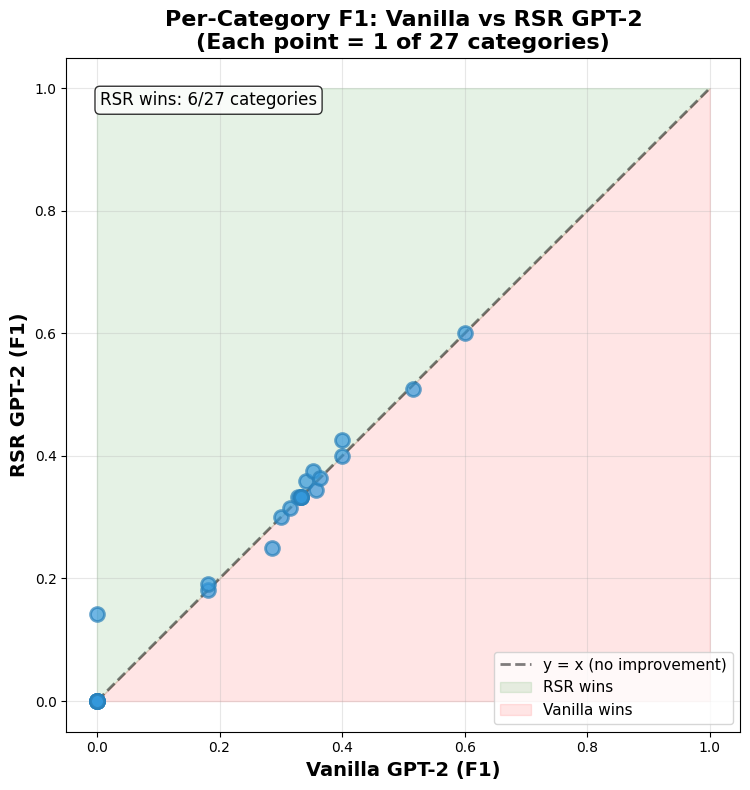

In [16]:
import matplotlib.pyplot as plt

# Get per-category F1 scores for both models
def get_per_category_f1(X, Y, C=1.0, test_size=0.2, random_state=42):
    """Get F1 score for each category."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    f1_scores = []
    valid_categories = []
    
    for f in range(Y.shape[1]):
        y = Y[:, f]
        if np.all(y == y[0]):
            continue
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=test_size, random_state=random_state, stratify=y
        )
        clf = LogisticRegression(C=C, max_iter=1000)
        clf.fit(X_train, y_train)
        f1_scores.append(f1_score(y_test, clf.predict(X_test)))
        valid_categories.append(f)
    
    return np.array(f1_scores), valid_categories

# Get per-category scores
vanilla_f1_per_cat, valid_cats = get_per_category_f1(X_vanilla, Y)
rsr_f1_per_cat, _ = get_per_category_f1(X_rsr, Y)

# Create scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(vanilla_f1_per_cat, rsr_f1_per_cat, s=100, alpha=0.7, 
           c='#3498db', edgecolors='#2980b9', linewidth=2, zorder=3)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2, label='y = x (no improvement)')

ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.1, color='green', label='RSR wins')
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.1, color='red', label='Vanilla wins')

ax.set_xlabel('Vanilla GPT-2 (F1)', fontsize=14, fontweight='bold')
ax.set_ylabel('RSR GPT-2 (F1)', fontsize=14, fontweight='bold')
ax.set_title('Per-Category F1: Vanilla vs RSR GPT-2\n(Each point = 1 of 27 categories)', fontsize=16, fontweight='bold')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=11)

n_rsr_wins = np.sum(rsr_f1_per_cat > vanilla_f1_per_cat)
n_total = len(vanilla_f1_per_cat)
ax.text(0.05, 0.95, f'RSR wins: {n_rsr_wins}/{n_total} categories', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


## Bonus: Nearest Neighbor Analysis


In [17]:
def cosine_sim(a, b):
    return float(np.dot(a, b) / (norm(a) * norm(b) + 1e-8))

def nearest_neighbors(word, embeddings_dict, k=5):
    if word not in embeddings_dict:
        return []
    vec = embeddings_dict[word]
    sims = [(w, cosine_sim(vec, v)) for w, v in embeddings_dict.items() if w != word]
    return sorted(sims, key=lambda x: x[1], reverse=True)[:k]

# Create word -> embedding dicts for THINGS concepts
vanilla_things_dict = {c: X_vanilla[i] for i, c in enumerate(valid_concepts)}
rsr_things_dict = {c: X_rsr[i] for i, c in enumerate(valid_concepts)}

# Compare nearest neighbors
test_words = ["cat", "dog", "car", "hammer", "apple"]

print("\n" + "="*70)
print("NEAREST NEIGHBOR COMPARISON (GPT-2)")
print("="*70 + "\n")

for word in test_words:
    if word not in vanilla_things_dict:
        continue
    print(f"=== '{word}' ===")
    print("VANILLA:", [w for w, _ in nearest_neighbors(word, vanilla_things_dict, 5)])
    print("RSR:    ", [w for w, _ in nearest_neighbors(word, rsr_things_dict, 5)])
    print()



NEAREST NEIGHBOR COMPARISON (GPT-2)

=== 'cat' ===
VANILLA: ['catfish', 'catapult', 'backscratcher', 'crayfish', 'bat1']
RSR:     ['catfish', 'catapult', 'backscratcher', 'bat1', 'crayfish']

=== 'dog' ===
VANILLA: ['dogfood', 'hotdog', 'bulldozer', 'catfish', 'backscratcher']
RSR:     ['dogfood', 'hotdog', 'bulldozer', 'catfish', 'sawhorse']

=== 'car' ===
VANILLA: ['car_door', 'car_seat', 'sidecar', 'carrot', 'caramel']
RSR:     ['car_door', 'car_seat', 'sidecar', 'carrot', 'carousel']

=== 'hammer' ===
VANILLA: ['jackhammer', 'sledgehammer', 'rollerblade', 'knife', 'forklift']
RSR:     ['jackhammer', 'sledgehammer', 'rollerblade', 'knife', 'forklift']

=== 'apple' ===
VANILLA: ['apple_tree', 'pineapple', 'blueberry', 'sweet_potato', 'peanut_butter']
RSR:     ['apple_tree', 'pineapple', 'blueberry', 'sweet_potato', 'blackberry']

